In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Audio, display
from pynwb import NWBHDF5IO

import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, IntSlider, FloatSlider, Dropdown, Checkbox

from brain_audio_decoder import BrainAudioDecoder
from custom_decoder import CustomBrainAudioDecoder
from brain_audio_decoder_viz import BrainAudioDecoderViz
from acoustic_change_detector import AcousticChangeDetector
from phoneme_validator import PhonemeValidator
from simplified_phoneme_model import SimplifiedPhonemeModel

In [2]:
# Define paths
path_bids = './SingleWordProductionDutch-iBIDS'  # Path to the BIDS dataset
path_output = './features'  # Path to save extracted features
path_results = './results'  # Path to save results

In [3]:
feature_extraction_method = 'multi_band' #'high_gamma'

In [4]:
# Initialize the custom decoder
custom_decoder = CustomBrainAudioDecoder(
        path_bids=path_bids,
        path_output=path_output,
        path_results=path_results,
        debug_mode=True
    )

CustomBrainAudioDecoder: Initializing CustomBrainAudioDecoder with debug_mode=True
CustomBrainAudioDecoder [DEBUG]: Initialized additional models for comparison


In [5]:
print("Loading participants and extracting features...")
custom_decoder.load_participants()

Loading participants and extracting features...
Found 10 participants:
  1. sub-01
  2. sub-02
  3. sub-03
  4. sub-04
  5. sub-05
  6. sub-06
  7. sub-07
  8. sub-08
  9. sub-09
  10. sub-10


,participant_id,age,sex,hand
0,sub-01,20,F,NaN
1,sub-02,43,M,NaN
2,sub-03,24,M,NaN
3,sub-04,46,F,NaN
4,sub-05,50,F,NaN
5,sub-06,16,M,NaN
6,sub-07,47,M,NaN
7,sub-08,22,F,NaN
8,sub-09,20,F,NaN
9,sub-10,36,M,NaN


In [6]:
print("Stratifying participants...")
participant_strata = custom_decoder.stratify_participants_by_channel_quality(
        channel_correlation_threshold=0.1
    )

Stratifying participants...
CustomBrainAudioDecoder [DEBUG]: Stratifying participants based on channel quality...
CustomBrainAudioDecoder [DEBUG]: Analyzing channels for sub-01...
CustomBrainAudioDecoder [DEBUG]: Analyzing channels for sub-02...
CustomBrainAudioDecoder [DEBUG]: Analyzing channels for sub-03...
CustomBrainAudioDecoder [DEBUG]: Analyzing channels for sub-04...
CustomBrainAudioDecoder [DEBUG]: Analyzing channels for sub-05...
CustomBrainAudioDecoder [DEBUG]: Analyzing channels for sub-06...
CustomBrainAudioDecoder [DEBUG]: Analyzing channels for sub-07...
CustomBrainAudioDecoder [DEBUG]: Analyzing channels for sub-08...
CustomBrainAudioDecoder [DEBUG]: Analyzing channels for sub-09...
CustomBrainAudioDecoder [DEBUG]: Analyzing channels for sub-10...
CustomBrainAudioDecoder: 
Participant stratification results:
CustomBrainAudioDecoder:   Participants with most relevant channels: 3
CustomBrainAudioDecoder:   Participants with relevant channels: 4
CustomBrainAudioDecoder:   

In [7]:
print("Creating stratified cross-word split...")
split_result = custom_decoder.create_stratified_cross_word_split(
        participant_strata=participant_strata,
        test_ratio=0.2,
        min_word_freq=1,
        random_seed=42
    )    

Creating stratified cross-word split...
CustomBrainAudioDecoder: Segmenting data for sub-06...
CustomBrainAudioDecoder [DEBUG]: Segmenting data by words for sub-06...
CustomBrainAudioDecoder [DEBUG]: Loaded 307594 word markers
CustomBrainAudioDecoder [DEBUG]: First 10 word markers: ['hoe' 'hoe' 'hoe' 'hoe' 'hoe' 'hoe' 'hoe' 'hoe' 'hoe' 'hoe']
CustomBrainAudioDecoder [DEBUG]: Found 100 word onsets
CustomBrainAudioDecoder [DEBUG]: First 5 word onsets: [(0, 'hoe'), (3077, 'zevenduizend'), (6152, 'en'), (9228, 'het'), (12302, 'smeekte')]
CustomBrainAudioDecoder [DEBUG]: Found 100 unique words with at least 1 occurrences
CustomBrainAudioDecoder [DEBUG]: Word 'hoe': 1 instances
CustomBrainAudioDecoder [DEBUG]: Word 'zevenduizend': 1 instances
CustomBrainAudioDecoder [DEBUG]: Word 'en': 1 instances
CustomBrainAudioDecoder [DEBUG]: Word 'het': 1 instances
CustomBrainAudioDecoder [DEBUG]: Word 'smeekte': 1 instances
CustomBrainAudioDecoder [DEBUG]: Word statistics:
CustomBrainAudioDecoder [DEBU

CustomBrainAudioDecoder [DEBUG]: Loaded 307579 word markers
CustomBrainAudioDecoder [DEBUG]: First 10 word markers: ['de' 'de' 'de' 'de' 'de' 'de' 'de' 'de' 'de' 'de']
CustomBrainAudioDecoder [DEBUG]: Found 100 word onsets
CustomBrainAudioDecoder [DEBUG]: First 5 word onsets: [(0, 'de'), (3076, 'buurt'), (6153, 'verstijfde'), (9231, 'zonlicht'), (12307, 'zevenduizend')]
CustomBrainAudioDecoder [DEBUG]: Found 100 unique words with at least 1 occurrences
CustomBrainAudioDecoder [DEBUG]: Word 'de': 1 instances
CustomBrainAudioDecoder [DEBUG]: Word 'buurt': 1 instances
CustomBrainAudioDecoder [DEBUG]: Word 'verstijfde': 1 instances
CustomBrainAudioDecoder [DEBUG]: Word 'zonlicht': 1 instances
CustomBrainAudioDecoder [DEBUG]: Word 'zevenduizend': 1 instances
CustomBrainAudioDecoder [DEBUG]: Word statistics:
CustomBrainAudioDecoder [DEBUG]:   Total unique words: 100
CustomBrainAudioDecoder [DEBUG]:   Total word instances: 100
CustomBrainAudioDecoder [DEBUG]: 
Overlap statistics:
CustomBrainA

In [8]:
from acoustic_change_detector import AcousticChangeDetector
detector = AcousticChangeDetector(
        min_segment_duration=0.03,
        max_segment_duration=0.3,
        distance_metric='cosine',
        smoothing_window=3,
        peak_threshold=0.5,
        decoder=custom_decoder,
        debug_mode=True
    )
detector.split_result = split_result

AcousticChangeDetector: Initialized with DEBUG_MODE=True


In [9]:
# Process multiple batches to build a comprehensive training set
# of phoneme segments with their corresponding EEG features
train = detector.accumulate_phoneme_data(
        num_batches=10,
        batch_size=32,
        feature_extraction_method = feature_extraction_method
    )
print(f"Accumulated {train['metadata']['n_phonemes']} training phoneme segments")
print(f"Found {train['metadata']['unique_phonemes']} unique phonemes")

AcousticChangeDetector: Accumulating train data from 10 batches...
AcousticChangeDetector: Processing batch 1/10
AcousticChangeDetector [DEBUG]: Processing batch with 32 instances
AcousticChangeDetector [DEBUG]: Original batch keys: ['eeg_segments', 'audio_segments', 'words', 'participant_ids', 'metadata', 'spectrogram_segments']
AcousticChangeDetector [DEBUG]: EEG segments in batch: True
AcousticChangeDetector [DEBUG]: Spectrogram segments in batch: True
AcousticChangeDetector [DEBUG]: Processing instance 0/32: 12
AcousticChangeDetector [DEBUG]: Added EEG segment with shape (3078, 127)
AcousticChangeDetector [DEBUG]: Detecting boundaries for word: 12
AcousticChangeDetector [DEBUG]: Estimated 4 phonemes for '12'
AcousticChangeDetector [DEBUG]: Added EEG segment with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Detecting boundaries for word: mij
AcousticChangeDetector [DEBUG]: Estimated 2 phonemes for 'mij'
AcousticChangeDetector [DEBUG]: Added EEG segment with shape (3078, 122)
Ac

AcousticChangeDetector [DEBUG]: Processing segment 3 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 4 with shape (3077, 115)
AcousticChangeDetector [DEBUG]: Processing segment 5 with shape (3076, 54)
AcousticChangeDetector [DEBUG]: Processing segment 6 with shape (3071, 117)
AcousticChangeDetector [DEBUG]: Processing segment 7 with shape (3077, 127)
AcousticChangeDetector [DEBUG]: Processing segment 8 with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Processing segment 9 with shape (3076, 60)
AcousticChangeDetector [DEBUG]: Processing segment 10 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 11 with shape (2647, 122)
AcousticChangeDetector [DEBUG]: Processing segment 12 with shape (3078, 127)
AcousticChangeDetector [DEBUG]: Processing segment 13 with shape (3077, 127)
AcousticChangeDetector [DEBUG]: Processing segment 14 with shape (3078, 122)
AcousticChangeDetector [DEBUG]: Processing segment 15 with shape (3076, 127)
Acoustic

AcousticChangeDetector [DEBUG]: Processing segment 1 with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Processing segment 2 with shape (3078, 122)
AcousticChangeDetector [DEBUG]: Processing segment 3 with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Processing segment 4 with shape (3074, 115)
AcousticChangeDetector [DEBUG]: Processing segment 5 with shape (3076, 54)
AcousticChangeDetector [DEBUG]: Processing segment 6 with shape (3079, 117)
AcousticChangeDetector [DEBUG]: Processing segment 7 with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Processing segment 8 with shape (3077, 127)
AcousticChangeDetector [DEBUG]: Processing segment 9 with shape (3076, 60)
AcousticChangeDetector [DEBUG]: Processing segment 10 with shape (3073, 127)
AcousticChangeDetector [DEBUG]: Processing segment 11 with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Processing segment 12 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 13 with shape (3077, 117)
AcousticCh

AcousticChangeDetector [DEBUG]: Enhanced batch contains 154 phoneme segments
AcousticChangeDetector [DEBUG]: Found 33 unique phonemes
AcousticChangeDetector [DEBUG]: Preparing phoneme-level training data...
AcousticChangeDetector [DEBUG]: Successfully imported extractHG function
AcousticChangeDetector [DEBUG]: Found 32 valid phoneme segments out of 32
AcousticChangeDetector [DEBUG]: Processing segment 0 with shape (3081, 127)
AcousticChangeDetector [DEBUG]: Processing segment 1 with shape (3079, 127)
AcousticChangeDetector [DEBUG]: Processing segment 2 with shape (3079, 122)
AcousticChangeDetector [DEBUG]: Processing segment 3 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 4 with shape (3076, 115)
AcousticChangeDetector [DEBUG]: Processing segment 5 with shape (3081, 54)
AcousticChangeDetector [DEBUG]: Processing segment 6 with shape (3075, 117)
AcousticChangeDetector [DEBUG]: Processing segment 7 with shape (3077, 127)
AcousticChangeDetector [DEBUG]: Process

AcousticChangeDetector [DEBUG]: Processing segment 1 with shape (3077, 127)
AcousticChangeDetector [DEBUG]: Processing segment 2 with shape (3077, 122)
AcousticChangeDetector [DEBUG]: Processing segment 3 with shape (3074, 127)
AcousticChangeDetector [DEBUG]: Processing segment 4 with shape (3077, 115)
AcousticChangeDetector [DEBUG]: Processing segment 5 with shape (3075, 54)
AcousticChangeDetector [DEBUG]: Processing segment 6 with shape (3073, 117)
AcousticChangeDetector [DEBUG]: Processing segment 7 with shape (3072, 127)
AcousticChangeDetector [DEBUG]: Processing segment 8 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 9 with shape (3074, 60)
AcousticChangeDetector [DEBUG]: Processing segment 10 with shape (3073, 127)
AcousticChangeDetector [DEBUG]: Processing segment 11 with shape (3073, 115)
AcousticChangeDetector [DEBUG]: Processing segment 12 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 13 with shape (3074, 127)
AcousticCh

...

AcousticChangeDetector [DEBUG]: Processing segment 1 with shape (3074, 127)
AcousticChangeDetector [DEBUG]: Processing segment 2 with shape (3080, 122)
AcousticChangeDetector [DEBUG]: Processing segment 3 with shape (3077, 127)
AcousticChangeDetector [DEBUG]: Processing segment 4 with shape (3078, 115)
AcousticChangeDetector [DEBUG]: Processing segment 5 with shape (3081, 54)
AcousticChangeDetector [DEBUG]: Processing segment 6 with shape (3071, 117)
AcousticChangeDetector [DEBUG]: Processing segment 7 with shape (3074, 127)
AcousticChangeDetector [DEBUG]: Processing segment 8 with shape (3073, 127)
AcousticChangeDetector [DEBUG]: Processing segment 9 with shape (3075, 60)
AcousticChangeDetector [DEBUG]: Processing segment 10 with shape (3076, 60)
AcousticChangeDetector [DEBUG]: Processing segment 11 with shape (3077, 127)
AcousticChangeDetector [DEBUG]: Processing segment 12 with shape (3071, 115)
AcousticChangeDetector [DEBUG]: Processing segment 13 with shape (3077, 60)
AcousticChan

AcousticChangeDetector [DEBUG]: Processing segment 1 with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Processing segment 2 with shape (3080, 122)
AcousticChangeDetector [DEBUG]: Processing segment 3 with shape (3077, 127)
AcousticChangeDetector [DEBUG]: Processing segment 4 with shape (3075, 115)
AcousticChangeDetector [DEBUG]: Processing segment 5 with shape (3073, 54)
AcousticChangeDetector [DEBUG]: Processing segment 6 with shape (3075, 117)
AcousticChangeDetector [DEBUG]: Processing segment 7 with shape (3073, 127)
AcousticChangeDetector [DEBUG]: Processing segment 8 with shape (3079, 127)
AcousticChangeDetector [DEBUG]: Processing segment 9 with shape (3075, 60)
AcousticChangeDetector [DEBUG]: Processing segment 10 with shape (3074, 54)
AcousticChangeDetector [DEBUG]: Processing segment 11 with shape (2647, 122)
AcousticChangeDetector [DEBUG]: Processing segment 12 with shape (3071, 115)
AcousticChangeDetector [DEBUG]: Processing segment 13 with shape (3077, 122)
AcousticCha

AcousticChangeDetector [DEBUG]: Processing segment 1 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 2 with shape (3079, 122)
AcousticChangeDetector [DEBUG]: Processing segment 3 with shape (3073, 127)
AcousticChangeDetector [DEBUG]: Processing segment 4 with shape (3078, 115)
AcousticChangeDetector [DEBUG]: Processing segment 5 with shape (3075, 54)
AcousticChangeDetector [DEBUG]: Processing segment 6 with shape (3077, 117)
AcousticChangeDetector [DEBUG]: Processing segment 7 with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Processing segment 8 with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Processing segment 9 with shape (3074, 60)
AcousticChangeDetector [DEBUG]: Processing segment 10 with shape (3076, 60)
AcousticChangeDetector [DEBUG]: Processing segment 11 with shape (3076, 117)
AcousticChangeDetector [DEBUG]: Processing segment 12 with shape (3071, 127)
AcousticChangeDetector [DEBUG]: Processing segment 13 with shape (3077, 122)
AcousticCha

AcousticChangeDetector [DEBUG]: Processing segment 1 with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Processing segment 2 with shape (3079, 122)
AcousticChangeDetector [DEBUG]: Processing segment 3 with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Processing segment 4 with shape (3071, 115)
AcousticChangeDetector [DEBUG]: Processing segment 5 with shape (3076, 54)
AcousticChangeDetector [DEBUG]: Processing segment 6 with shape (3076, 117)
AcousticChangeDetector [DEBUG]: Processing segment 7 with shape (3073, 127)
AcousticChangeDetector [DEBUG]: Processing segment 8 with shape (3077, 127)
AcousticChangeDetector [DEBUG]: Processing segment 9 with shape (3074, 60)
AcousticChangeDetector [DEBUG]: Processing segment 10 with shape (3074, 54)
AcousticChangeDetector [DEBUG]: Processing segment 11 with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Processing segment 12 with shape (3071, 115)
AcousticChangeDetector [DEBUG]: Processing segment 13 with shape (3074, 54)
AcousticChan

AcousticChangeDetector [DEBUG]: Processing segment 1 with shape (3074, 127)
AcousticChangeDetector [DEBUG]: Processing segment 2 with shape (3078, 122)
AcousticChangeDetector [DEBUG]: Processing segment 3 with shape (3074, 127)
AcousticChangeDetector [DEBUG]: Processing segment 4 with shape (3076, 115)
AcousticChangeDetector [DEBUG]: Processing segment 5 with shape (3076, 54)
AcousticChangeDetector [DEBUG]: Processing segment 6 with shape (3078, 117)
AcousticChangeDetector [DEBUG]: Processing segment 7 with shape (3077, 127)
AcousticChangeDetector [DEBUG]: Processing segment 8 with shape (3079, 127)
AcousticChangeDetector [DEBUG]: Processing segment 9 with shape (3074, 60)
AcousticChangeDetector [DEBUG]: Processing segment 10 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 11 with shape (3077, 127)
AcousticChangeDetector [DEBUG]: Processing segment 12 with shape (3071, 127)
AcousticChangeDetector [DEBUG]: Processing segment 13 with shape (3076, 127)
AcousticCh

In [10]:
# Similar to training data accumulation but for the test set
test = detector.accumulate_phoneme_data(
        num_batches=3,
        batch_size=32,
        feature_extraction_method = feature_extraction_method
    )
print(f"Accumulated {test['metadata']['n_phonemes']} test phoneme segments")   

AcousticChangeDetector: Accumulating train data from 3 batches...
AcousticChangeDetector: Processing batch 1/3
AcousticChangeDetector [DEBUG]: Processing batch with 32 instances
AcousticChangeDetector [DEBUG]: Original batch keys: ['eeg_segments', 'audio_segments', 'words', 'participant_ids', 'metadata', 'spectrogram_segments']
AcousticChangeDetector [DEBUG]: EEG segments in batch: True
AcousticChangeDetector [DEBUG]: Spectrogram segments in batch: True
AcousticChangeDetector [DEBUG]: Processing instance 0/32: wat
AcousticChangeDetector [DEBUG]: Added EEG segment with shape (3078, 127)
AcousticChangeDetector [DEBUG]: Detecting boundaries for word: wat
AcousticChangeDetector [DEBUG]: Estimated 2 phonemes for 'wat'
AcousticChangeDetector [DEBUG]: Added EEG segment with shape (3070, 127)
AcousticChangeDetector [DEBUG]: Detecting boundaries for word: juist
AcousticChangeDetector [DEBUG]: Estimated 4 phonemes for 'juist'
AcousticChangeDetector [DEBUG]: Added EEG segment with shape (3077, 12

AcousticChangeDetector [DEBUG]: Processing segment 4 with shape (3076, 115)
AcousticChangeDetector [DEBUG]: Processing segment 5 with shape (3074, 54)
AcousticChangeDetector [DEBUG]: Processing segment 6 with shape (3078, 117)
AcousticChangeDetector [DEBUG]: Processing segment 7 with shape (3077, 127)
AcousticChangeDetector [DEBUG]: Processing segment 8 with shape (3078, 127)
AcousticChangeDetector [DEBUG]: Processing segment 9 with shape (3075, 60)
AcousticChangeDetector [DEBUG]: Processing segment 10 with shape (3074, 54)
AcousticChangeDetector [DEBUG]: Processing segment 11 with shape (3073, 115)
AcousticChangeDetector [DEBUG]: Processing segment 12 with shape (3078, 127)
AcousticChangeDetector [DEBUG]: Processing segment 13 with shape (3077, 117)
AcousticChangeDetector [DEBUG]: Processing segment 14 with shape (3075, 54)
AcousticChangeDetector [DEBUG]: Processing segment 15 with shape (3075, 117)
AcousticChangeDetector [DEBUG]: Processing segment 16 with shape (3076, 115)
AcousticC

AcousticChangeDetector [DEBUG]: Processing segment 1 with shape (3077, 127)
AcousticChangeDetector [DEBUG]: Processing segment 2 with shape (3077, 122)
AcousticChangeDetector [DEBUG]: Processing segment 3 with shape (3066, 127)
AcousticChangeDetector [DEBUG]: Processing segment 4 with shape (3077, 115)
AcousticChangeDetector [DEBUG]: Processing segment 5 with shape (3077, 54)
AcousticChangeDetector [DEBUG]: Processing segment 6 with shape (3077, 117)
AcousticChangeDetector [DEBUG]: Processing segment 7 with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Processing segment 8 with shape (3074, 127)
AcousticChangeDetector [DEBUG]: Processing segment 9 with shape (3074, 60)
AcousticChangeDetector [DEBUG]: Processing segment 10 with shape (3079, 117)
AcousticChangeDetector [DEBUG]: Processing segment 11 with shape (3077, 127)
AcousticChangeDetector [DEBUG]: Processing segment 12 with shape (3078, 127)
AcousticChangeDetector [DEBUG]: Processing segment 13 with shape (3075, 127)
AcousticCh

AcousticChangeDetector [DEBUG]: Enhanced batch contains 148 phoneme segments
AcousticChangeDetector [DEBUG]: Found 31 unique phonemes
AcousticChangeDetector [DEBUG]: Preparing phoneme-level training data...
AcousticChangeDetector [DEBUG]: Successfully imported extractHG function
AcousticChangeDetector [DEBUG]: Found 32 valid phoneme segments out of 32
AcousticChangeDetector [DEBUG]: Processing segment 0 with shape (3081, 127)
AcousticChangeDetector [DEBUG]: Processing segment 1 with shape (3072, 127)
AcousticChangeDetector [DEBUG]: Processing segment 2 with shape (3078, 122)
AcousticChangeDetector [DEBUG]: Processing segment 3 with shape (3077, 127)
AcousticChangeDetector [DEBUG]: Processing segment 4 with shape (3074, 115)
AcousticChangeDetector [DEBUG]: Processing segment 5 with shape (3080, 54)
AcousticChangeDetector [DEBUG]: Processing segment 6 with shape (3074, 117)
AcousticChangeDetector [DEBUG]: Processing segment 7 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Process

In [11]:
# 2. Resolve unknown phonemes using your existing approach
#Initialize the validator with a reference to the detector
validator = PhonemeValidator(detector=detector)
validator.enable_debug()
# For training data
train_converted = {
        'phoneme_labels': train['phoneme_labels'],
        'phoneme_spectrogram_segments': train.get('spectrograms', []),
        'phoneme_words': train['phoneme_words'],
        'phoneme_positions': train.get('phoneme_positions', [0] * len(train['phoneme_labels'])),
        'phoneme_participant_ids': train.get('phoneme_participant_ids', ['unknown'] * len(train['phoneme_labels']))
    }
    
print(f"Training data before resolution: {train_converted['phoneme_labels'].count('?')} unknown phonemes")
resolved_train = validator.resolve_unknown_phonemes(train_converted)
print(f"Training data after resolution: {resolved_train['phoneme_labels'].count('?')} unknown phonemes")
    
# Update the training data with resolved phonemes
train['phoneme_labels'] = resolved_train['phoneme_labels']
    
# For test data
test_converted = {
        'phoneme_labels': test['phoneme_labels'],
        'phoneme_spectrogram_segments': test.get('spectrograms', []),
        'phoneme_words': test['phoneme_words'],
        'phoneme_positions': test.get('phoneme_positions', [0] * len(test['phoneme_labels'])),
        'phoneme_participant_ids': test.get('phoneme_participant_ids', ['unknown'] * len(test['phoneme_labels']))
    }
    
print(f"Test data before resolution: {test_converted['phoneme_labels'].count('?')} unknown phonemes")
resolved_test = validator.resolve_unknown_phonemes(test_converted)
print(f"Test data after resolution: {resolved_test['phoneme_labels'].count('?')} unknown phonemes")
    
# Update the test data with resolved phonemes
test['phoneme_labels'] = resolved_test['phoneme_labels']

PhonemeValidator: Initialized with DEBUG_MODE=False
PhonemeValidator: Debug mode enabled
Training data before resolution: 51 unknown phonemes
PhonemeValidator [DEBUG]: Attempting to resolve 51 unknown phonemes
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'maantje' as 'm'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'maantje' as 'm'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'maantje' as 'm'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'maantje' as 'm'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'maantje' as 'm'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'of' as 'ɔf'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'of' as 'ɔf'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'of' as 'ɔf'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'of' as 'ɔf'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'of' as 'ɔf'
PhonemeValidator [DEBUG]: Resolved phone

In [12]:
phoneme_viz = validator.visualize_phoneme_spectrograms(
    phoneme_data={
        'phoneme_labels': train['phoneme_labels'],
        'spectrograms': train['spectrograms'],
        'phoneme_words': train['phoneme_words'],
        'phoneme_participant_ids': train['phoneme_participant_ids'],
        'phoneme_positions': train.get('phoneme_positions', [0] * len(train['phoneme_labels']))
    },
    target_phonemes= None,  # ['m', 'ɛ', 'œy', 'n', 't'] Choose specific phonemes to visualize
    max_examples=7,  # Show up to 3 examples per phoneme
    participant_filter=None,  # Set to a participant ID to filter by participant
    save_dir='./results/phoneme_visualizations',
    show_stats=True  # Show statistics about each phoneme
)

print(f"Phoneme visualizations saved to ./results/phoneme_visualizations")

PhonemeValidator: Found 41 unique phonemes in the data
PhonemeValidator: Visualization for phoneme 'n' saved to ./results/phoneme_visualizations\phoneme_n.png
PhonemeValidator: Visualization for phoneme 't' saved to ./results/phoneme_visualizations\phoneme_t.png
PhonemeValidator: Visualization for phoneme 'r' saved to ./results/phoneme_visualizations\phoneme_r.png
PhonemeValidator: Visualization for phoneme 'ɑ' saved to ./results/phoneme_visualizations\phoneme_a_back.png
PhonemeValidator: Visualization for phoneme 'œy' saved to ./results/phoneme_visualizations\phoneme_oe_y.png
PhonemeValidator: Visualization for phoneme 'ə' saved to ./results/phoneme_visualizations\phoneme_schwa.png
PhonemeValidator: Visualization for phoneme 'l' saved to ./results/phoneme_visualizations\phoneme_l.png
PhonemeValidator: Visualization for phoneme 's' saved to ./results/phoneme_visualizations\phoneme_s.png
PhonemeValidator: Visualization for phoneme 'd' saved to ./results/phoneme_visualizations\phoneme_d.

In [13]:
total_words = sum(len(participant_data) for participant_data in detector.split_result['train'].values())
total_test_words = sum(len(participant_data) for participant_data in detector.split_result['test'].values())
print(f"Total training words: {total_words}, Total test words: {total_test_words}")

Total training words: 790, Total test words: 205


In [14]:
from collections import Counter
phoneme_counts = Counter(train['phoneme_labels'])
print("Phoneme distribution:")
for phoneme, count in phoneme_counts.most_common():
    print(f"  {phoneme}: {count}")

Phoneme distribution:
  n: 27
  t: 21
  r: 21
  ɑ: 20
  œy: 17
  ə: 17
  l: 15
  s: 14
  d: 13
  m: 11
  ɛi: 10
  f: 9
  h: 9
  k: 9
  v: 9
  ɛ: 8
  ɔf: 8
  aː: 7
  ˌ: 7
  oː: 7
  ɣ: 5
  x: 5
  ɪ: 5
  b: 5
  eː: 5
  z: 5
  tʋ: 4
  ʏ: 4
  a: 4
  ɔ: 3
  i: 3
  ʋ: 2
  p: 2
  øː: 2
  iː: 1
  uː: 1
  ʋɪ: 1
  ʋɑ: 1
  sx: 1
  ɪx: 1
  ŋ: 1


In [15]:
# 3. Add phoneme groups to PhoneticDictionary
phonetic_dict = detector.phonetic_dict
if not hasattr(phonetic_dict, 'phoneme_groups'):
    phonetic_dict.add_phoneme_groups()
    
# 4. Map phonemes to phoneme groups
print("Mapping phonemes to phoneme groups...")
train_group_labels = [phonetic_dict.get_phoneme_group(p) or 'unknown' for p in train['phoneme_labels']]
test_group_labels = [phonetic_dict.get_phoneme_group(p) or 'unknown' for p in test['phoneme_labels']] 

Mapping phonemes to phoneme groups...


In [16]:
# Create a minimal version that doesn't try to reinvent your pipeline
model = SimplifiedPhonemeModel(
        phonetic_dict=phonetic_dict,
        output_dir=os.path.join(path_results, 'simplified_phoneme_model'),
        debug_mode=True
    )

SimplifiedPhonemeModel: Initialized SimplifiedPhonemeModel with 7 phoneme groups
SimplifiedPhonemeModel [DEBUG]: Phoneme groups: {'front_vowels': ['i', 'ɪ', 'e', 'ɛ', 'ɛi', 'y', 'ʏ'], 'back_vowels': ['u', 'o', 'ɔ', 'a', 'ɑ', 'ɑu', 'œy', 'ə'], 'labial': ['p', 'b', 'f', 'v', 'm'], 'alveolar': ['t', 'd', 's', 'z', 'n', 'l'], 'palatal': ['ŋ', 'j', 'r', 'tʃ', 'dʒ', 'tɕ', 'dʑ'], 'dorsal': ['k', 'g', 'x', 'ɣ', 'ŋ', 'χ', 'ʁ'], 'glottal': ['h', 'ɦ', 'ʔ']}


SimplifiedPhonemeModel: Training model with pre-processed phoneme group data
SimplifiedPhonemeModel: Phoneme group distribution before filtering:
SimplifiedPhonemeModel:   alveolar: 95
SimplifiedPhonemeModel:   back_vowels: 61
SimplifiedPhonemeModel:   unknown: 48
SimplifiedPhonemeModel:   labial: 36
SimplifiedPhonemeModel:   front_vowels: 30
SimplifiedPhonemeModel:   palatal: 21
SimplifiedPhonemeModel:   dorsal: 20
SimplifiedPhonemeModel:   glottal: 9
SimplifiedPhonemeModel: Training with 320 samples (filtered from 320)
SimplifiedPhonemeModel: Phoneme group distribution after filtering:
SimplifiedPhonemeModel:   alveolar: 95
SimplifiedPhonemeModel:   back_vowels: 61
SimplifiedPhonemeModel:   unknown: 48
SimplifiedPhonemeModel:   labial: 36
SimplifiedPhonemeModel:   front_vowels: 30
SimplifiedPhonemeModel:   palatal: 21
SimplifiedPhonemeModel:   dorsal: 20
SimplifiedPhonemeModel:   glottal: 9
SimplifiedPhonemeModel: Testing with 96 samples (filtered from 96)
SimplifiedPhonemeModel: Sta

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ eeg_input (InputLayer)        │ (None, 296, 50)           │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d (Conv1D)               │ (None, 296, 32)           │           8,032 │ eeg_input[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 296, 32)           │             128 │ conv1d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling1d (MaxPooling1D)  │ (None, 148, 32)           │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_1 (Conv1D)             │ (None, 148, 64)           │          10,304 │ max_pooling1d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 148, 64)           │             256 │ conv1d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling1d_1               │ (None, 74, 64)            │               0 │ batch_normalization_1[0][… │
│ (MaxPooling1D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional (Bidirectional) │ (None, 128)               │          66,048 │ max_pooling1d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 128)               │               0 │ bidirectional[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ participant_input             │ (None, 10)                │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 64)                │           8,256 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 16)                │             176 │ participant_input[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 64)                │             256 │ dense[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 16)                │              64 │ dense_1[0][0]              │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 94,168 (367.84 KB)

 Trainable params: 93,816 (366.47 KB)

 Non-trainable params: 352 (1.38 KB)

SimplifiedPhonemeModel: Training model with 320 samples for up to 50 epochs
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.1131 - loss: 3.1866 - val_accuracy: 0.0729 - val_loss: 2.1615 - learning_rate: 5.0000e-04
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1500 - loss: 2.9654 - val_accuracy: 0.0521 - val_loss: 2.1658 - learning_rate: 5.0000e-04
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2044 - loss: 2.9281 - val_accuracy: 0.0729 - val_loss: 2.1555 - learning_rate: 5.0000e-04
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.1537 - loss: 2.8545 - val_accuracy: 0.0833 - val_loss: 2.1503 - learning_rate: 5.0000e-04
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.1921 - loss: 2.4729 - val_accuracy: 0.1042 - val_loss: 2.1363 - learning_rate: 5.0000e-04
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.2129 - loss: 2.5800 - val_accuracy: 0.1250 - val_loss: 2.1190 - learning_rate: 5.000

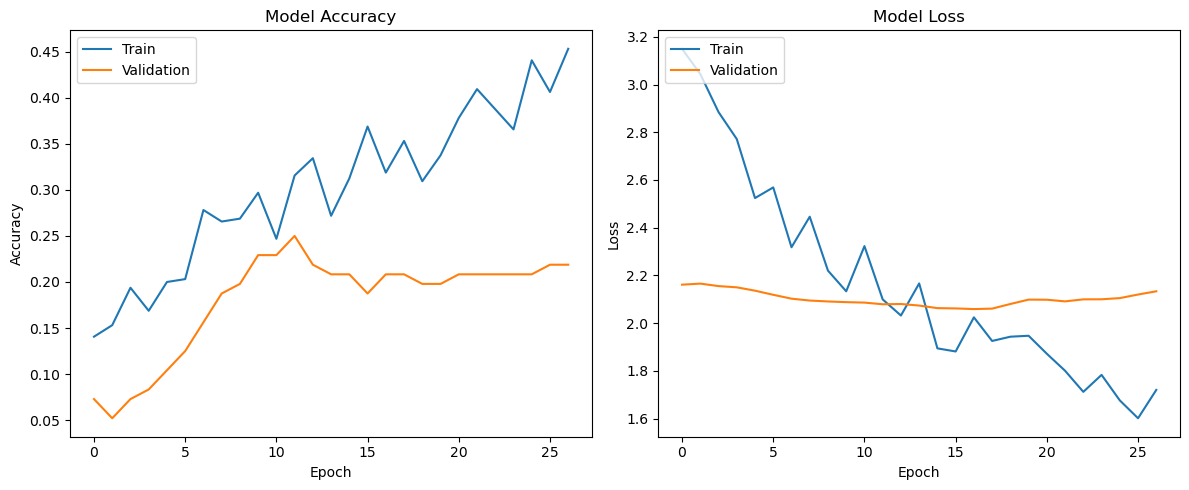

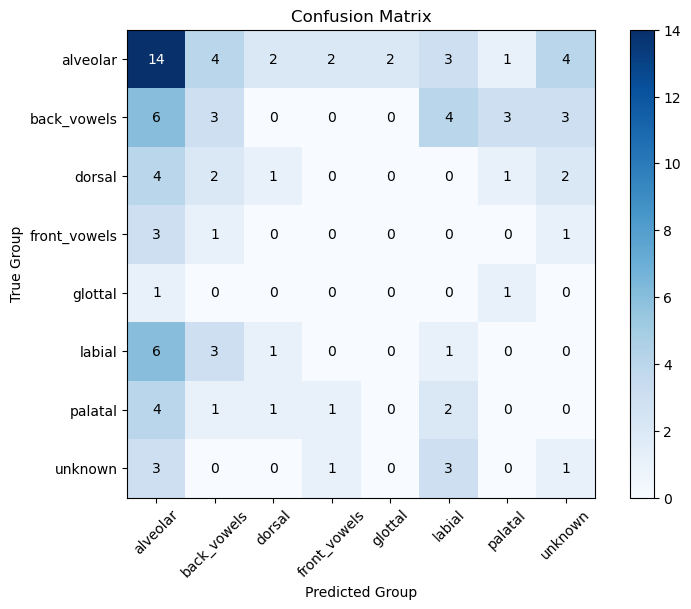

In [17]:
# 6. Train using your phoneme groups
results = model.train_with_grouped_data(
        train_features=train['features'],
        train_group_labels=train_group_labels,
        train_participant_ids=train['phoneme_participant_ids'],
        test_features=test['features'],
        test_group_labels=test_group_labels,
        test_participant_ids=test['phoneme_participant_ids'],
        epochs=50,
        batch_size=32,
        patience=10
    )

In [18]:
# 7. Evaluate performance
print(f"Simplified phoneme group model accuracy: {results['accuracy']:.4f}")
    
# Compare to baseline
baseline_results = custom_decoder.train_test_model(
        participant_id='sub-08',
        save_audio=False
    )
baseline_correlation = np.mean(baseline_results['correlations'])
print(f"Baseline model correlation: {baseline_correlation:.4f}") 

Simplified phoneme group model accuracy: 0.2083
Training and testing model for sub-08...
sub-08 has mean correlation of 0.7152
Baseline model correlation: 0.7152


SimplifiedPhonemeModel: Detailed confusion matrix saved to ./results\simplified_phoneme_model\detailed_confusion_matrix.png


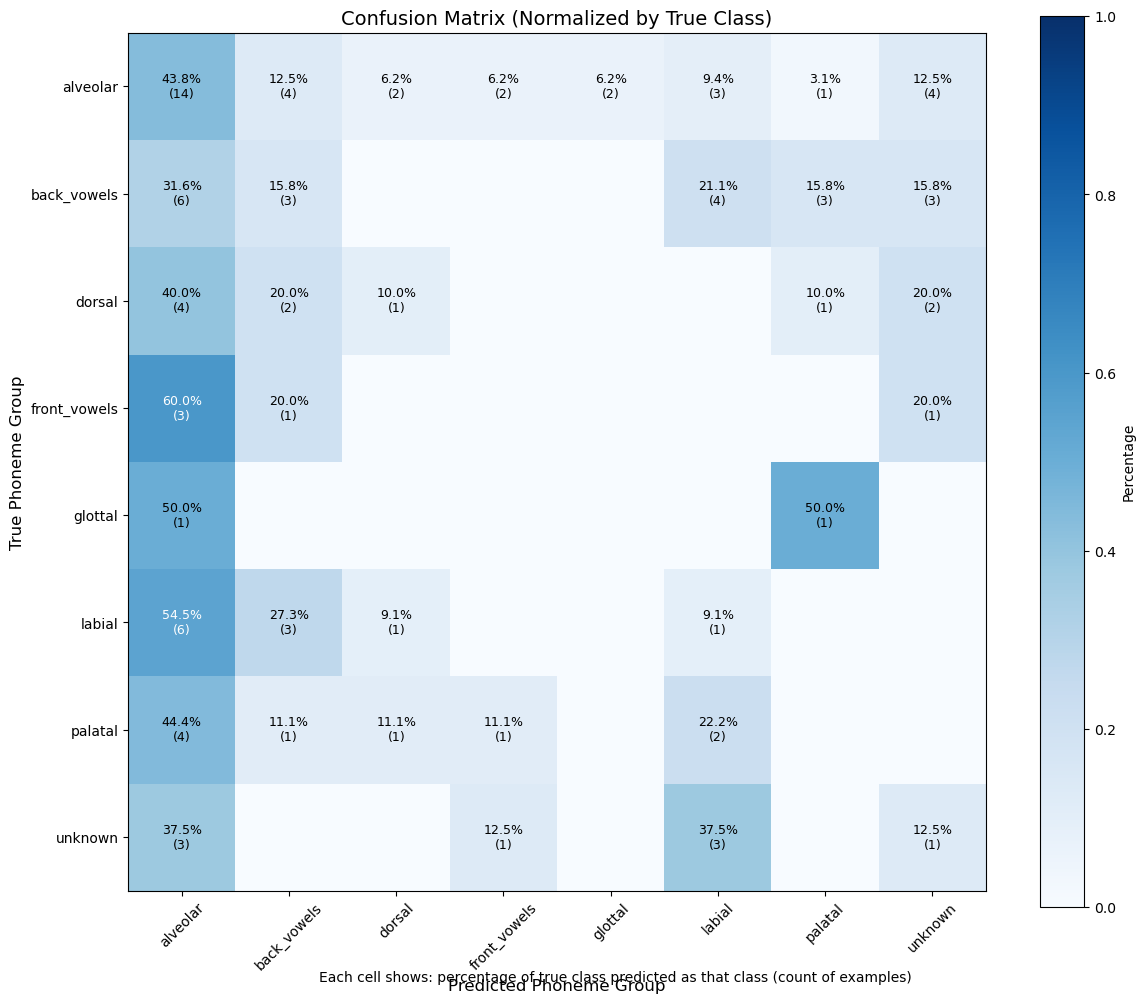

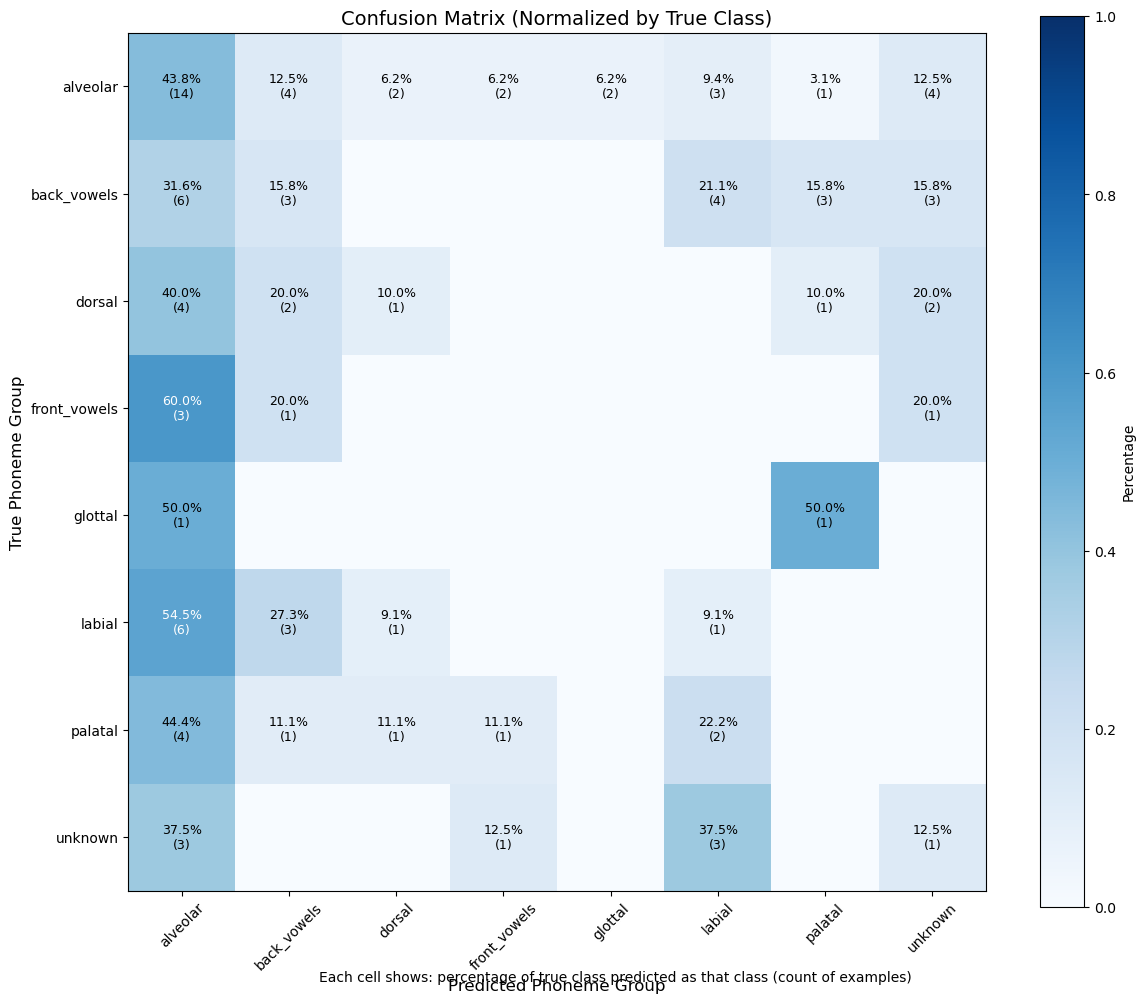

In [19]:
# Create a detailed confusion matrix
model.plot_detailed_confusion_matrix(results['confusion_matrix'])    


D:\Documents\UM DACS\bachelor\UM DACS\bachelor\mozg\code\SingleWordProductionDutch\simplified_phoneme_model.py:998: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(metrics_df['Phoneme Group'], rotation=45)


SimplifiedPhonemeModel: Class performance analysis saved to ./results\simplified_phoneme_model\class_performance.png
SimplifiedPhonemeModel: Class metrics saved to ./results\simplified_phoneme_model\class_metrics.csv


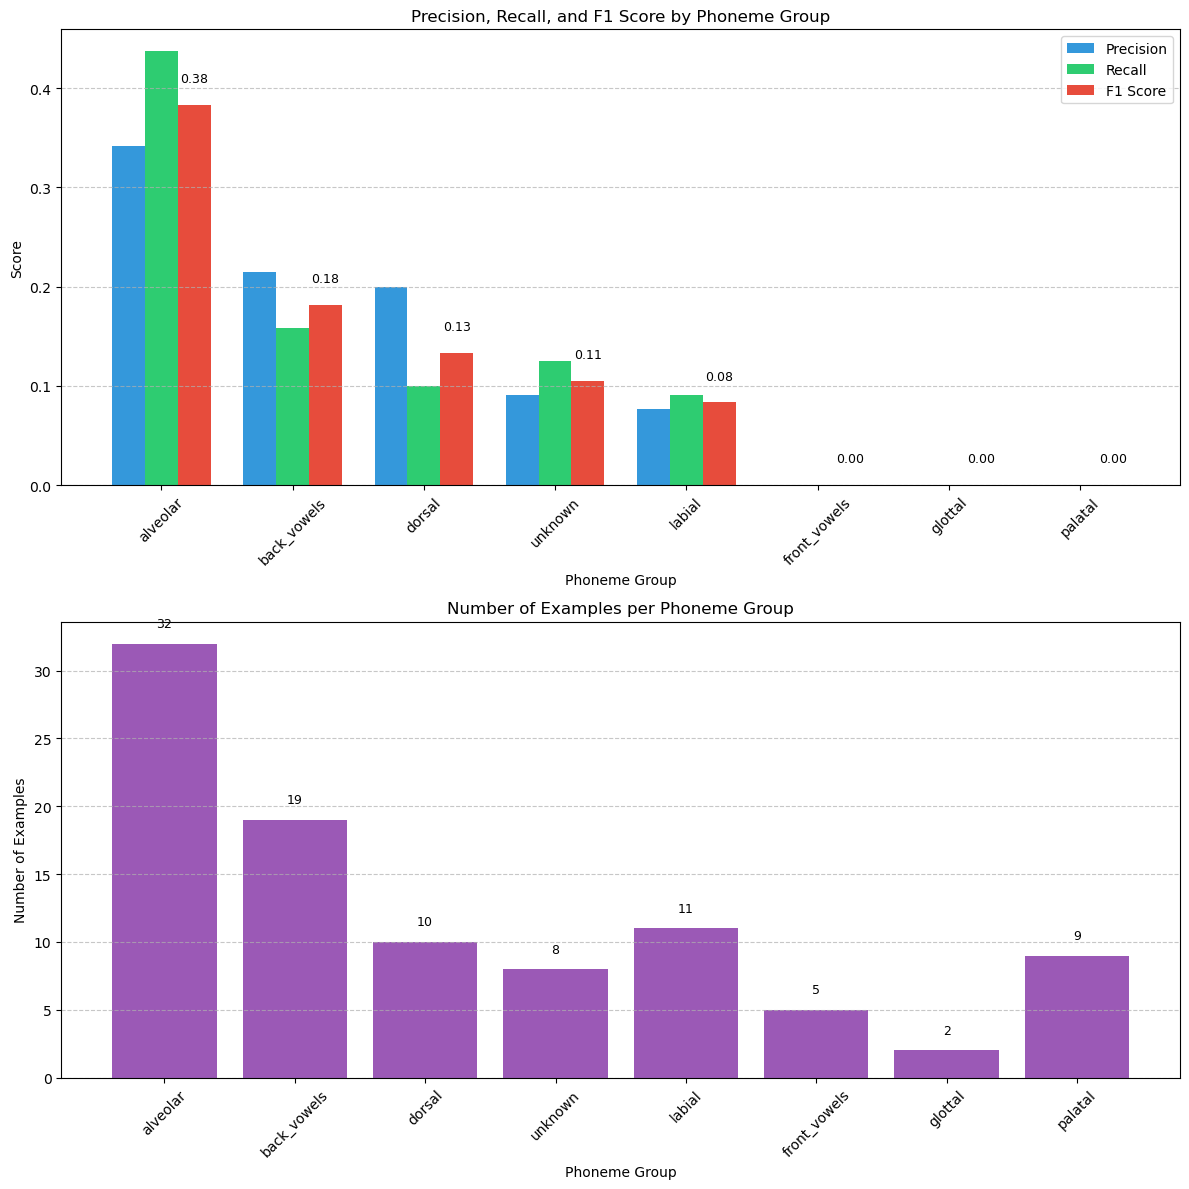

In [20]:
class_metrics = model.analyze_class_performance(
        results['true_groups'], 
        results['predicted_groups'],
        results['predictions']
    )   


In [21]:
# Analyze example predictions
examples = model.analyze_examples(
        test['features'],
        results['true_groups'],
        results['predicted_groups'],
        test['phoneme_participant_ids'],
        max_examples=3
    )  


SimplifiedPhonemeModel: Examples for 'alveolar' saved to ./results\simplified_phoneme_model\examples\examples_alveolar.png
SimplifiedPhonemeModel: Examples for 'back_vowels' saved to ./results\simplified_phoneme_model\examples\examples_back_vowels.png
SimplifiedPhonemeModel: Examples for 'dorsal' saved to ./results\simplified_phoneme_model\examples\examples_dorsal.png
SimplifiedPhonemeModel: Examples for 'front_vowels' saved to ./results\simplified_phoneme_model\examples\examples_front_vowels.png
SimplifiedPhonemeModel: Examples for 'glottal' saved to ./results\simplified_phoneme_model\examples\examples_glottal.png
SimplifiedPhonemeModel: Examples for 'labial' saved to ./results\simplified_phoneme_model\examples\examples_labial.png
SimplifiedPhonemeModel: Examples for 'palatal' saved to ./results\simplified_phoneme_model\examples\examples_palatal.png
SimplifiedPhonemeModel: Examples for 'unknown' saved to ./results\simplified_phoneme_model\examples\examples_unknown.png
SimplifiedPhonem